In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv(
    r"D:\Project_Olist_clean\customer_ml.csv",
    skipinitialspace=True,   # bỏ dấu cách đầu ô
    low_memory=False         # đọc đúng kiểu dữ liệu, tránh DtypeWarning
)
df.columns = df.columns.str.strip()   # bỏ dấu cách thừa ở tên cột
df.head()

,customer_unique_id,first_order_value,first_category,first_review_score,first_delivery_days,first_late_order,customer_state,first_payment_type,first_payment_installments,repeat_90d,payment_installments
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,bed_bath_table,5.0,6.41,0,SP,credit_card,8.0,0,8.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,health_beauty,4.0,3.29,0,SP,credit_card,1.0,0,1.0
2,0000f46a3911fa3c0805444483337064,86.22,stationery,3.0,25.73,0,SC,credit_card,8.0,0,8.0
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,telephony,4.0,20.04,0,PA,credit_card,4.0,0,4.0
4,0004aac84e0df4da2b147fca70cf8255,196.89,unknown,5.0,13.14,0,SP,credit_card,6.0,0,6.0


In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())

customer_unique_id            0
first_order_value             0
first_category                0
first_review_score            0
first_delivery_days           0
first_late_order              0
customer_state                0
first_payment_type            0
first_payment_installments    1
repeat_90d                    0
payment_installments          0
dtype: int64
0


In [5]:
df.dtypes

customer_unique_id                str
first_order_value             float64
first_category                    str
first_review_score            float64
first_delivery_days           float64
first_late_order                int64
customer_state                    str
first_payment_type                str
first_payment_installments    float64
repeat_90d                      int64
payment_installments          float64
dtype: object

### Làm sạch dữ liệu (dấu cách thừa, ô trống, ép kiểu số)

In [6]:
num_cols = [
    'first_order_value', 'first_review_score', 'first_delivery_days',
    'first_late_order', 'first_payment_installments', 'payment_installments'
]
categorical_cols = ['first_category', 'customer_state', 'first_payment_type']

# 1) Cột chuỗi: bỏ dấu cách 2 đầu, ô rỗng -> NaN
for c in df.select_dtypes(exclude='number').columns:
    df[c] = df[c].astype('string').str.strip().replace('', pd.NA)

# 2) Cột số: ép về số (ô toàn dấu cách / chữ -> NaN)
for c in num_cols + ['repeat_90d']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# 3) Cột phân loại: NaN -> 'unknown' (để one-hot không mất dòng)
for c in categorical_cols:
    df[c] = df[c].fillna('unknown').astype(str)

print("NaN sau khi làm sạch:")
print(df.isnull().sum())

# Dòng thiếu target thì bỏ (không thể huấn luyện)
df = df.dropna(subset=['repeat_90d']).copy()
df['repeat_90d'] = df['repeat_90d'].astype(int)

NaN sau khi làm sạch:
customer_unique_id            0
first_order_value             0
first_category                0
first_review_score            0
first_delivery_days           0
first_late_order              0
customer_state                0
first_payment_type            0
first_payment_installments    1
repeat_90d                    0
payment_installments          0
dtype: int64


In [7]:
df.dtypes

customer_unique_id             string
first_order_value             float64
first_category                    str
first_review_score            float64
first_delivery_days           float64
first_late_order                int64
customer_state                    str
first_payment_type                str
first_payment_installments    float64
repeat_90d                      int64
payment_installments          float64
dtype: object

In [8]:
df['repeat_90d'].value_counts()

repeat_90d
0    73790
1     1514
Name: count, dtype: int64

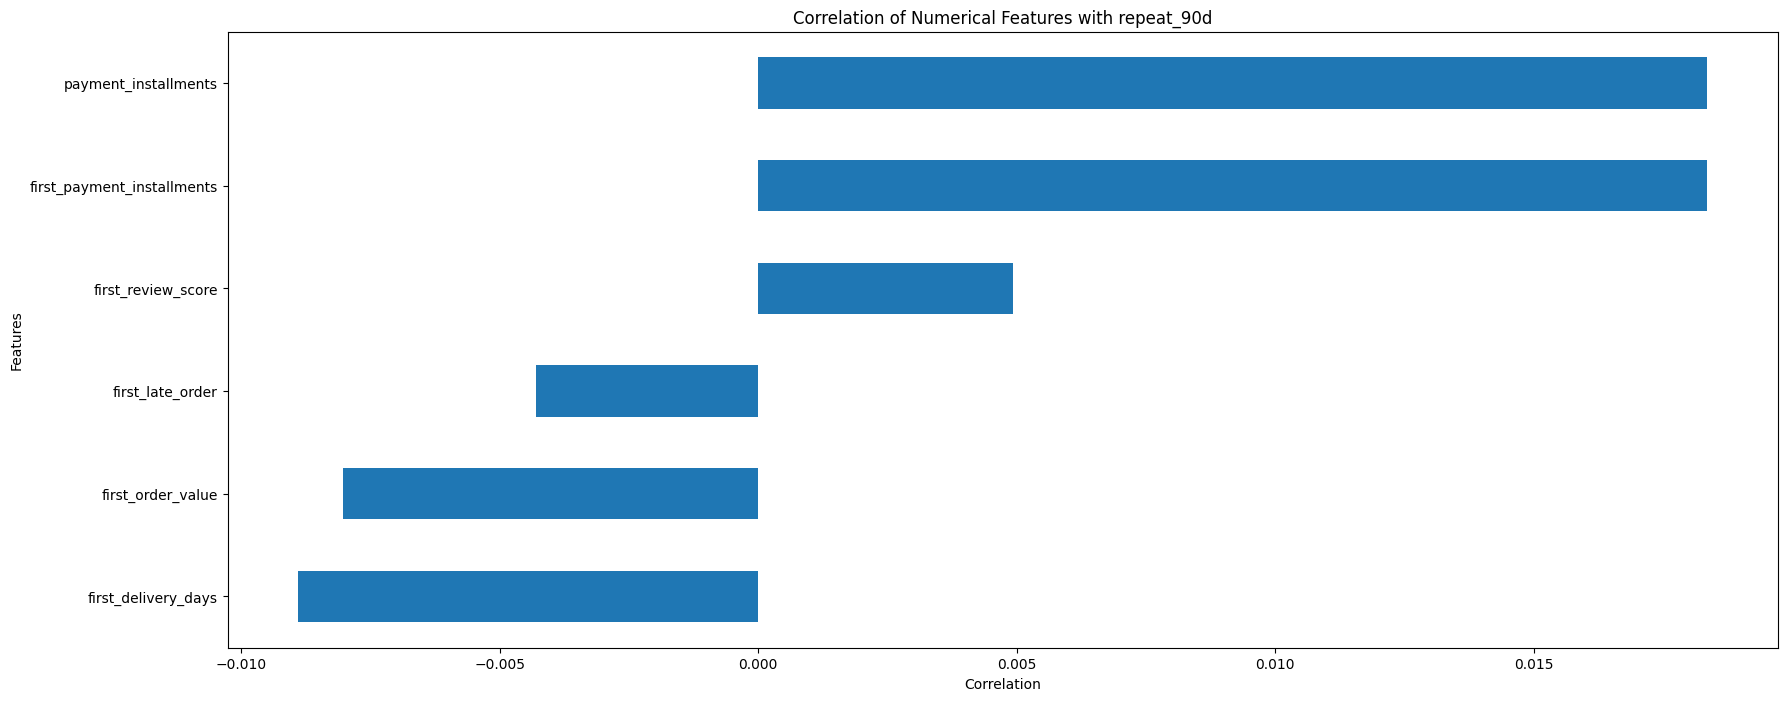

In [9]:
numeric_df = df.select_dtypes(include="number")

corr = (
    numeric_df
    .corr()["repeat_90d"]
    .drop("repeat_90d")
    .sort_values()
)

plt.figure(figsize=(20, 8))

corr.plot(kind="barh")

plt.title("Correlation of Numerical Features with repeat_90d")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()

In [10]:
X = df.drop(columns=["customer_unique_id", "repeat_90d"])
y = df["repeat_90d"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

X shape: (75304, 9)
y shape: (75304,)

Target distribution:
repeat_90d
0    73790
1     1514
Name: count, dtype: int64

Target percentage:
repeat_90d
0    97.989483
1     2.010517
Name: proportion, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:")
print(y_train.value_counts())

X_train: (60243, 9)
X_test : (15061, 9)
y_train:
repeat_90d
0    59032
1     1211
Name: count, dtype: int64


### Xử lý NaN còn lại (median của tập train, tránh data leakage)

In [12]:
for col in num_cols:
    med = X_train[col].median()
    X_train[col] = X_train[col].fillna(med)
    X_test[col]  = X_test[col].fillna(med)

print("NaN train:", X_train[num_cols].isnull().sum().sum(),
      "| NaN test:", X_test[num_cols].isnull().sum().sum())

NaN train: 0 | NaN test: 0


### One-Hot

In [13]:
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False)
X_test  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=False)

# Đảm bảo train/test có cùng columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# bool -> int để mọi cột đều là số
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

###  StandardScaler

In [14]:
cols_to_scale = [
    'first_order_value',
    'first_review_score',
    'first_delivery_days',
    'first_payment_installments',
    'payment_installments'
]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print(X_train.head())

       first_order_value  first_review_score  first_delivery_days  \
63451          -0.514533            0.669778            -1.156581   
14844          -0.539397            0.669778            -0.907022   
68595          -0.471159            0.669778             0.257917   
3773           -0.553520            0.669778            -0.332040   
71419          -0.487339            0.669778            -1.200503   

       first_late_order  first_payment_installments  payment_installments  \
63451               0.0                   -0.709771             -0.709771   
14844               0.0                   -0.709771             -0.709771   
68595               0.0                   -0.709771             -0.709771   
3773                0.0                   -0.709771             -0.709771   
71419               0.0                   -0.342746             -0.342746   

       first_category_agro_industry_and_commerce  \
63451                                        0.0   
14844             

### SMOTE

In [15]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
repeat_90d
0    59032
1    59032
Name: count, dtype: int64


### LogisticRegression + SMOTE

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_smote, y_train_smote)


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


print("=== Random Forest + SMOTE ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", average_precision_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))



=== Random Forest + SMOTE ===
Accuracy : 0.5332315251311334
Precision: 0.02432470654787159
Recall   : 0.5676567656765676
F1-score : 0.04665039327366423
ROC-AUC  : 0.588105483539274
PR-AUC   : 0.03212662183352411

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.53      0.69     14758
           1       0.02      0.57      0.05       303

    accuracy                           0.53     15061
   macro avg       0.50      0.55      0.37     15061
weighted avg       0.96      0.53      0.68     15061


Confusion matrix:
[[7859 6899]
 [ 131  172]]


### RandomForestClassifier + SMOTE

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest + SMOTE ===")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC   :", average_precision_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest + SMOTE ===
Accuracy : 0.8109687271761503
Precision: 0.02466367713004484
Recall   : 0.21782178217821782
F1-score : 0.044310171198388724
ROC-AUC  : 0.5636553559136913
PR-AUC   : 0.025196650012588636

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.82      0.90     14758
           1       0.02      0.22      0.04       303

    accuracy                           0.81     15061
   macro avg       0.50      0.52      0.47     15061
weighted avg       0.96      0.81      0.88     15061



### HistGradientBoostingClassifier + SMOTE

In [18]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.1,
    max_iter=200,
    random_state=42
)

hgb_model.fit(X_train_smote, y_train_smote)

y_pred_hgb = hgb_model.predict(X_test)
y_prob_hgb = hgb_model.predict_proba(X_test)[:, 1]

print("=== HistGradientBoosting + SMOTE ===")

print("Accuracy :", accuracy_score(y_test, y_pred_hgb))
print("Precision:", precision_score(y_test, y_pred_hgb))
print("Recall   :", recall_score(y_test, y_pred_hgb))
print("F1-score :", f1_score(y_test, y_pred_hgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_hgb))
print("PR-AUC   :", average_precision_score(y_test, y_prob_hgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_hgb))

=== HistGradientBoosting + SMOTE ===
Accuracy : 0.9158754398778302
Precision: 0.021825396825396824
Recall   : 0.07260726072607261
F1-score : 0.033562166285278416
ROC-AUC  : 0.5495302206735106
PR-AUC   : 0.027408663406484804

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     14758
           1       0.02      0.07      0.03       303

    accuracy                           0.92     15061
   macro avg       0.50      0.50      0.49     15061
weighted avg       0.96      0.92      0.94     15061



In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.base import clone
from imblearn.pipeline import Pipeline

def get_oof_probability(model, X_train, y_train):

    pipeline = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", clone(model))
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    oof_probability = cross_val_predict(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    return oof_probability

In [20]:
from sklearn.metrics import precision_recall_curve

def find_best_threshold(y_true, y_probability):

    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_probability
    )

    beta = 2

    f2_score = (
        (1 + beta**2) * precision * recall
        / (beta**2 * precision + recall + 1e-9)
    )

    # Bỏ phần tử cuối vì thresholds ít hơn precision/recall 1 phần tử
    f2_score = f2_score[:-1]

    best_index = np.argmax(f2_score)

    best_threshold = thresholds[best_index]

    return best_threshold


In [21]:
# Lấy xác suất OOF trên TRAIN
oof_probability = get_oof_probability(
    model,
    X_train,
    y_train
)

# Tìm threshold tốt nhất
best_threshold = find_best_threshold(
    y_train,
    oof_probability
)

print("Threshold tốt nhất:", round(best_threshold, 4))

Threshold tốt nhất: 0.5411


In [22]:
from sklearn.metrics import fbeta_score
# Áp dụng threshold mới lên TEST
y_pred_new = (y_prob >= best_threshold).astype(int)

print(f"=== Logistic Regression + SMOTE | threshold = {best_threshold:.4f} ===")
print("Precision:", precision_score(y_test, y_pred_new, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_new))
print("F1-score :", f1_score(y_test, y_pred_new))
print("F2-score :", fbeta_score(y_test, y_pred_new, beta=2))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob), "(không đổi)")
print("PR-AUC   :", average_precision_score(y_test, y_prob), "(không đổi)")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_new))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_new, zero_division=0))

=== Logistic Regression + SMOTE | threshold = 0.5411 ===
Precision: 0.02645721372467962
Recall   : 0.42244224422442245
F1-score : 0.049795759579848276
F2-score : 0.10578512396694215
ROC-AUC  : 0.588105483539274 (không đổi)
PR-AUC   : 0.03212662183352411 (không đổi)

Confusion matrix:
[[10048  4710]
 [  175   128]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.68      0.80     14758
           1       0.03      0.42      0.05       303

    accuracy                           0.68     15061
   macro avg       0.50      0.55      0.43     15061
weighted avg       0.96      0.68      0.79     15061



In [23]:
from imblearn.pipeline import Pipeline
pipeline_lr = Pipeline([
    ("smote", SMOTE(
        random_state=42
    )),
    
    ("lr", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [27]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
param_grid_lr = {
    
    "lr__C": [
        0.001,
        0.01,
        0.05,
        0.1,
        0.5,
        1,
        2,
        5,
        10
    ],
    
    "lr__solver": [
        "liblinear",
        "lbfgs"
    ],
    
    "lr__class_weight": [
        None,
        "balanced"
    ]
}
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


In [28]:
grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
grid_lr.fit(X_train, y_train)
print("===== BEST PARAMETERS =====")

print(grid_lr.best_params_)

print("\n===== BEST CV RECALL =====")

print(grid_lr.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
===== BEST PARAMETERS =====
{'lr__C': 5, 'lr__class_weight': None, 'lr__solver': 'lbfgs'}

===== BEST CV RECALL =====
0.5830017345168861


In [32]:
best_lr = grid_lr.best_estimator_

print(best_lr)

y_pred_tuned = best_lr.predict(X_test)

y_prob_tuned = best_lr.predict_proba(X_test)[:, 1]

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('lr',
                 LogisticRegression(C=5, max_iter=2000, random_state=42))])


In [33]:
print("==========================================")
print(" Logistic Regression + SMOTE + TUNING")
print("==========================================")

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))

print("Precision:", precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
))

print("Recall   :", recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
))

print("F1-score :", f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
))

print("F2-score :", fbeta_score(
    y_test,
    y_pred_tuned,
    beta=2,
    zero_division=0
))

print("ROC-AUC  :", roc_auc_score(
    y_test,
    y_prob_tuned
))

print("PR-AUC   :", average_precision_score(
    y_test,
    y_prob_tuned
))

print("\n===== Classification Report =====")

print(
    classification_report(
        y_test,
        y_pred_tuned,
        zero_division=0
    )
)

print("\n===== Confusion Matrix =====")

cm = confusion_matrix(
    y_test,
    y_pred_tuned
)

print(cm)

 Logistic Regression + SMOTE + TUNING
Accuracy : 0.5320363853661776
Precision: 0.024262942587106786
Recall   : 0.5676567656765676
F1-score : 0.046536796536796536
F2-score : 0.10360197566558246
ROC-AUC  : 0.5876622490816638
PR-AUC   : 0.03204165957058834

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.98      0.53      0.69     14758
           1       0.02      0.57      0.05       303

    accuracy                           0.53     15061
   macro avg       0.50      0.55      0.37     15061
weighted avg       0.96      0.53      0.68     15061


===== Confusion Matrix =====
[[7841 6917]
 [ 131  172]]
